In [692]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import warnings  as war
war.filterwarnings("ignore")


### we want to make the feature for X and Y 
#### formula for Y =b + wX + w2X^2 + w3X^3

In [693]:
X=np.linspace(0,6,40)
X
Y_T=4 + 0.2*X + 4*X**2 + 0.1*X**3
Y_T


array([  4.        ,   4.12580792,   4.44314975,   4.95421029,
         5.66117433,   6.56622667,   7.67155212,   8.97933546,
        10.49176149,  12.21101502,  14.13928084,  16.27874374,
        18.63158853,  21.2       ,  23.98616295,  26.99226218,
        30.22048248,  33.67300865,  37.35202549,  41.2597178 ,
        45.39827037,  49.769868  ,  54.37669549,  59.22093764,
        64.30477924,  69.6304051 ,  75.2       ,  81.01574875,
        87.07983614,  93.39444697,  99.96176604, 106.78397815,
       113.86326809, 121.20182066, 128.80182066, 136.66545289,
       144.79490214, 153.19235321, 161.8599909 , 170.8       ])

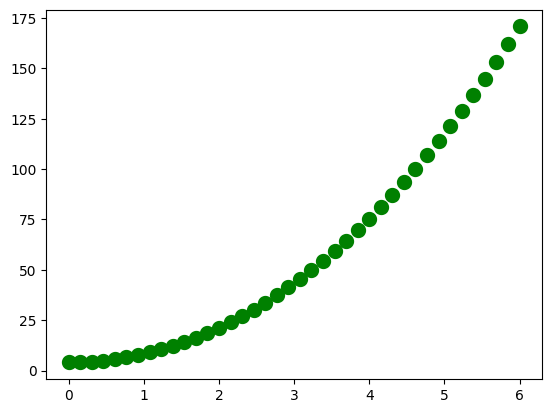

In [694]:
plt.scatter(X,Y_T,c='g',linewidths= 5)

### we add the noise 

In [695]:
Y=Y_T + np.random.normal(0,10,len(X))
Y

array([ 14.43914113,  -4.39533582,  11.46343594, -12.2697799 ,
        29.45147391,  12.11363274,  19.9507512 ,  11.68584595,
         5.12601433, -12.27785675,  23.17908113,   0.25572878,
        13.25169172,  23.78301754,  33.81131288,  16.20270979,
        35.43283346,  39.47767244,  32.74050967,  44.9866178 ,
        55.59931065,  53.76337814,  56.57210561,  56.8202979 ,
        82.48396789,  81.8705905 ,  73.03623498,  83.77556302,
        95.08656593,  69.03722434, 114.16028533, 104.86022621,
       106.53988634, 113.66101656, 119.60702904, 125.63696925,
       137.81544927, 143.17103889, 160.81060197, 157.9000283 ])

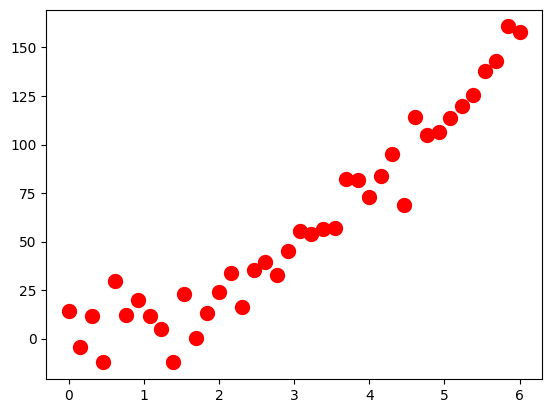

In [696]:
plt.scatter(X,Y,c='r',linewidths= 5)

In [697]:
X.shape

(40,)

In [698]:
from sklearn.model_selection import train_test_split

In [699]:
X=X.reshape(-1,1) ### convert into column -1 means that jetne value hai iuke barabr aik column banayo
X.shape

(40, 1)

In [700]:
print(Y.shape)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y)

(40,)


In [701]:
from sklearn.linear_model import LinearRegression


In [702]:
model=LinearRegression()

In [703]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [704]:
pred=model.predict(X_test)


In [705]:
pred.shape

(10,)

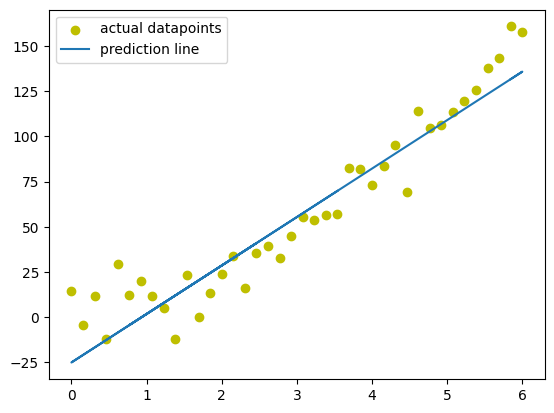

In [706]:
plt.scatter(X,Y,c='y',label="actual datapoints")
plt.plot(X_test,pred,label="prediction line")
plt.legend()
### these line does not represnt the data correctly 

In [707]:
from sklearn.metrics import r2_score 
r2_score(Y_test,pred)

0.8708264204032893

In [708]:
X_train_pred=model.predict(X_train)
X_test_pred=model.predict(X_test)
r2_score(Y_train,X_train_pred)
print("The training of the r2 is: ",r2_score(Y_train,X_train_pred))
print("the testing of r2 is :",r2_score(Y_test,X_test_pred)) 

The training of the r2 is:  0.9050662197502167
the testing of r2 is : 0.8708264204032893


## conclusion :
### This model is overfit becz the trainning accuracy is high and the testing accuarcy is low 


In [713]:
from sklearn.preprocessing import PolynomialFeatures
polyno=PolynomialFeatures(degree= 3,include_bias=False)
X_train_ploy=polyno.fit_transform(X_train)
X_test_ploy=polyno.fit_transform(X_test)
Curve=LinearRegression()
Curve.fit(X_train_ploy,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [714]:
### make prediction
prd=Curve.predict(X_test_ploy)
pred
predd=Curve.predict(X_train_ploy)
print("Prediction in X_train is :",predd)
print("prediction in X_test is :",prd)

Prediction in X_train is : [ 25.474526    42.58287375  10.54746038   7.14783092   6.08655988
 117.48009089 112.16195246 137.39033841 127.75146236   8.04137101
  84.62246285  47.39511361  79.07805809   6.60927582   8.6420955
  12.84203233  57.50852418  18.51122446  90.18388964 132.66090893
  68.12788764  52.37762817 101.27023639   5.71964034  37.96280182
 106.75136988  73.57256861  95.74044524 122.68389194  33.55679107]
prediction in X_test is : [ 62.76590842  21.84205817  10.03781917  12.62051352  29.38673471
   5.35057135   5.48017561  15.5039181  146.22157314 141.91785756]


In [715]:
print("Training R² :", r2_score(Y_train, predd))
print("Testing R²  :", r2_score(Y_test, prd))

Training R² : 0.947003077899122
Testing R²  : 0.9635189228133678


### plot it 

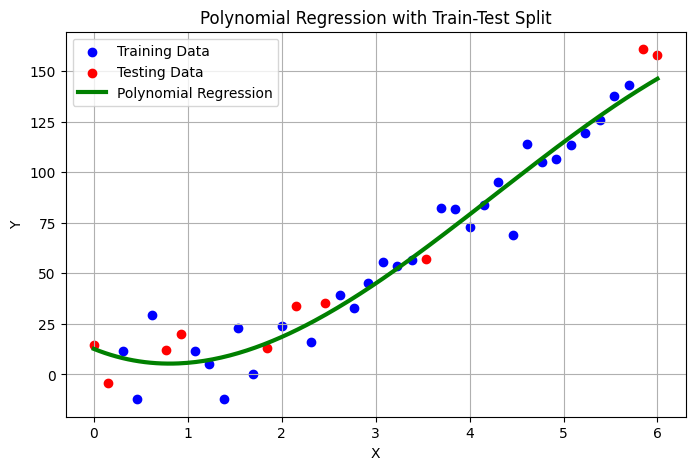

In [717]:
# Create smooth x values
x_smooth = np.linspace(0, 6, 200).reshape(-1, 1)

# Convert to polynomial features
X_smooth_poly = polyno.transform(x_smooth)

# Predict
y_smooth = Curve.predict(X_smooth_poly)

# Plot
plt.figure(figsize=(8,5))

plt.scatter(X_train, Y_train, color='blue', label='Training Data')
plt.scatter(X_test, Y_test, color='red', label='Testing Data')

plt.plot(x_smooth, y_smooth, color='green', linewidth=3,
         label='Polynomial Regression')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression with Train-Test Split")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(model.n_features_in_)

1


In [ ]:
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(degree=3, include_bias=False)

# X_train = poly.fit_transform(X.reshape(-1, 1))
# X_test = poly.fit_transform(X.reshape(-1, 1))
# print(X_train.shape)

# print(X_test.shape)



In [ ]:
Y_pred=model.predict(X_test)

In [ ]:
# Build polynomial features from scratch: x, x^2, x^3
x2 = X ** 2
x3 = X ** 3

# stack them into a feature matrix (each column is one feature)
X_poly = np.column_stack([X, x2, x3])
print("shape:", X_poly.shape, " (35 rows, 3 features: x, x², x³)")
print("first 3 rows:")
print(np.round(X_poly[:3], 2))

shape: (40, 3)  (35 rows, 3 features: x, x², x³)
first 3 rows:
[[0.   0.   0.  ]
 [0.15 0.02 0.  ]
 [0.31 0.09 0.03]]


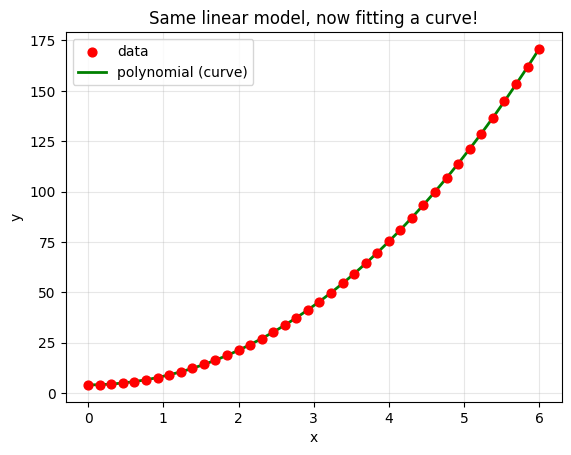

In [ ]:
curve_model = LinearRegression().fit(X_poly, Y_T)

# to draw a smooth curve, make dense x values and build their powers too
x_smooth = np.linspace(0, 6, 200)
X_smooth = np.column_stack([x_smooth, x_smooth**2, x_smooth**3])
y_smooth = curve_model.predict(X_smooth)

plt.scatter(X, Y_T, color="red", s=40, zorder=3, label="data")
plt.plot(x_smooth, y_smooth, color="green", linewidth=2, label="polynomial (curve)")
plt.xlabel("x"); 
plt.ylabel("y"); 
plt.title("Same linear model, now fitting a curve!")
plt.legend(); 
plt.grid(True, alpha=0.3)
plt.show()